In [5]:
%load_ext autoreload
%autoreload 2
from IPython.core.display import display, HTML
display(HTML("<style>.container { width:95% !important; }</style>"))
import sys
sys.path.insert(0, '/home/kat/Repos/SALSA/')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### 1) Compute properties from a sample of ChEMBL.

In [7]:
import pandas as pd
from rdkit.Chem import Descriptors
import torch
from rdkit import Chem
from rdkit.ML.Descriptors.MoleculeDescriptors import MolecularDescriptorCalculator

# This is ALL properties in Descriptors
desc_names = sorted([x[0] for x in Descriptors._descList])

## These are just the ones listed out in MolCLR that are releant imho.
c = pd.read_csv('selected_props_for_mahalanobis.csv')
prop_names = c['prop_name'].values.tolist()

def get_props(smiles, prop_list):
    calc = MolecularDescriptorCalculator(prop_list)
    props = calc.CalcDescriptors(Chem.MolFromSmiles(smiles))
    return torch.nan_to_num(torch.tensor(props),0.0).float()

In [8]:
import os
import numpy as np
from tqdm.notebook import tqdm
from property_predictors import surface_predictor
seedy = 666

# # # # # #
size = 10000 
# # # # # #

## Load ChEMBL.
ddir = '/home/kat/Repos/SALSA/data/'
df = pd.read_csv(os.path.join(ddir,'chembl_valid_lte_120.csv'))

## Get sample...
df_samp = df.sample(size, random_state=seedy)
df_samp = df_samp.reset_index(drop=True)
# display(df_samp)

## Calculate MolBert properties on sample.
_chembl_props = []
for sm in tqdm(df_samp.smiles.values,total=len(df_samp)):
    props = get_props(sm, prop_list=prop_names) # surface_predictor(sm) 
    _chembl_props.append(props)
_chembl_props = np.vstack([np.array(x) for x in _chembl_props])

  0%|          | 0/10000 [00:00<?, ?it/s]

### 2) Get properties for all training set compounds.

In [9]:
from contra_seq_dataset import get_dataset_array, get_anc_map
from joblib import Parallel, delayed

## Load in training set.
home = '/home/kat/Repos/SALSA/'
anc_path = f'{home}data/model_ready/01/train/anchor_smiles.csv'
aug_path = f'{home}data/model_ready/01/train/augmented_smiles.csv'
df = get_dataset_array(anc_path, aug_path)
anc_map = get_anc_map(df)

## Calculate props for the training set.
parallelizer = Parallel(n_jobs=-1, backend= 'multiprocessing' )
tasks = (delayed(get_props)(sm, prop_list=prop_names) for sm in df.smiles.values)
_train_props = parallelizer(tasks)
_train_props = np.vstack([np.array(x) for x in _train_props])

### 3) Get rid of all-zero and inf-containing properties in both the training set and chembl.

In [10]:
## Get rid of all-zero properties in chembl and train sets. (to ensure det!=0)
assert(_chembl_props.shape[1]==_train_props.shape[1])

to_drop = []
for i in range(_chembl_props.shape[1]):
    if np.isinf(_chembl_props[:,i]).any():
        to_drop.append(i) 
    if len(set(_chembl_props[:,i]))==1:
        to_drop.append(i)
        
    if np.isinf(_train_props[:,i]).any():
        to_drop.append(i) 
    if len(set(_train_props[:,i]))==1:
        to_drop.append(i)
        
to_keep = [i for i in range(_chembl_props.shape[1]) if i not in to_drop]
print(len(set(to_drop)), len(to_keep))

train_props = _train_props[:,to_keep]
chembl_props = _chembl_props[:,to_keep]
print(train_props.shape, chembl_props.shape)

6 84
(120000, 84) (10000, 84)


In [11]:
## Calculate covariance matrix.
cov = np.cov(chembl_props.T)

## Perturb covariance matrix to avoid complex values in inverse ...
# # # # # # # # # #
epsilon = 1e-14
cov_perturbed = cov + epsilon*np.eye(len(cov))

# inv_cov = np.linalg.inv(cov)
inv_cov = np.linalg.inv(cov_perturbed)
print(np.iscomplex(inv_cov).any())

to_drop = []
for i in range(inv_cov.shape[0]):
    if np.isinf(inv_cov[:,i]).any():
        to_drop.append(i) 

to_keep = [i for i in range(inv_cov.shape[0]) if i not in to_drop]
print(f'Drop: {len(set(to_drop))} Keep: {len(to_keep)}')

## Slice out valid bits
inv_cov_valid = inv_cov[to_keep,:][:,to_keep]
chembl_props_valid = chembl_props[:,to_keep] 
train_props_valid = train_props[:,to_keep]
print(inv_cov_valid.shape,chembl_props_valid.shape,train_props_valid.shape)

False
Drop: 0 Keep: 84
(84, 84) (10000, 84) (120000, 84)


### <font color=blue> Check that covariance matrix is positive (semi-)definite.

In [21]:
def is_pos_def(x):
    return np.all(np.linalg.eigvals(x) > 0)
def is_pos_semidef(x):
    return np.all(np.linalg.eigvals(x) >= 0)

print("Positive semi-definite?",is_pos_semidef(inv_cov_valid))
print("Positive definite?",is_pos_def(inv_cov_valid))

idc_indef_eigs = np.where(np.linalg.eigvals(inv_cov_valid) <= 0)[0]
print(idc_indef_eigs)

print(np.isnan(train_props).any())
print(np.min(train_props), np.max(train_props))

Positive semi-definite? True
Positive definite? True
[]
False
-22.509264 790.717


### 5) Get Mahalanobis distances between each anc-ang pair in the training set w.r.t the previously calculated ChEMBL property covariance matrix.

In [13]:
from scipy.spatial import distance
from itertools import combinations as combo
# np.seterr(all='print')

# # # # # # # # # # # # # #
far_thresh = 8
which_cov = inv_cov_valid
# # # # # # # # # # # # # #

paired_dists = np.full((len(df), len(df)), -1)

paired_dists_list = []
anc_aug_dists = []
far_pairs = []

for anc,augs in tqdm(anc_map.items(), total=len(anc_map)):
        
    augs = list(augs)
    augs.pop(0)
    
    prop_anc = train_props_valid[anc]    
    for aug in augs:
        
        prop_aug = train_props_valid[aug]
        d = distance.mahalanobis(prop_anc, prop_aug, VI=which_cov)
        paired_dists[anc][aug] = d   
        paired_dists_list.append([anc,aug,d])
        
        if d > far_thresh:
            far_pairs.append([anc,aug])
        anc_aug_dists.append(d)
        
dist_arr = np.array(anc_aug_dists)  
print('Total distances:',len(anc_aug_dists))
print('Far distance count:',len(far_pairs))
print('Nan count:',np.count_nonzero(np.isnan(dist_arr)))

  0%|          | 0/20000 [00:00<?, ?it/s]

Total distances: 100000
Far distance count: 5570
Nan count: 0


### 6) Look at some percentiles cutoffs.

In [14]:
dist_df = pd.DataFrame(dist_arr)
display(dist_df.describe())

qs = [0.9, 0.95, 0.99]
display(dist_df.quantile(qs))

,0
count,100000.000000
mean,3.628234
std,3.898840
min,0.000000
25%,2.278820
50%,2.857505
75%,4.012696
max,126.655586


,0
0.90,5.285735
0.95,8.664231
0.99,11.937563


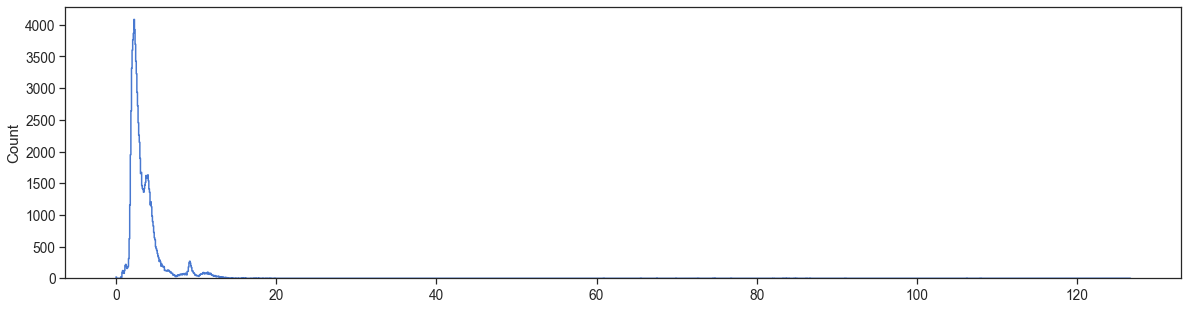

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_theme(style='ticks',font_scale=1.25,palette='muted')

plt.figure(figsize=(20,5))
sns.histplot(dist_arr, fill=False, element="step", kde=False) #, bw_adjust=.25)
plt.show()

### 7) Save shit for later.

In [18]:
df_paired = pd.DataFrame(paired_dists_list,columns=['anc_idx','aug_idx','distance'])

In [19]:
df_paired.to_csv('20220530_paired_dists.csv',index=False)
t = pd.read_csv('20220530_paired_dists.csv')
t

In [ ]:
# far_anc_to_augs = {}
# for anc,aug in far_pairs:
#     if anc in far_anc_to_augs.keys():
#         far_anc_to_augs[anc].append(aug)
#     else:
#         far_anc_to_augs[anc] = [aug]
        
# far_ancs = far_anc_to_augs.keys()
# df_far_ancs = pd.DataFrame(far_ancs,columns=['idx'])
# df_far_ancs['smiles'] = df_far_ancs.apply(lambda x: df.smiles.values[x])
# df_far_ancs['len'] = df_far_ancs.smiles.apply(lambda x: len(x))
# df_far_ancs = df_far_ancs.sort_values(by='len', ascending=True, ignore_index=True)
# df_far_ancs

In [ ]:
# from rdkit.Chem import AllChem
# from rdkit import Chem, Geometry
# from rdkit.Chem import Draw
# from rdkit.Chem.Draw import IPythonConsole

# def sm_and_mol(sm):
#     mol = Chem.MolFromSmiles(sm)
#     sm = Chem.MolToSmiles(mol)
#     display(sm,mol)
    
# smis = df.smiles.values

# for i,row in df_far_ancs.iterrows():
    
#     anc_idx = row.idx
#     anc_smi = smis[anc_idx]
    
#     mols = []
#     aug_idc = anc_map[anc_idx]
#     for aug_idx in aug_idc:
#         print(paired_dists[anc_idx][aug_idx])
#         aug_smi = smis[aug_idx]
#         mols.append(Chem.MolFromSmiles(aug_smi))
#     img = Draw.MolsToGridImage(mols, molsPerRow=len(mols), subImgSize=(250, 250))
#     display(img)
    
#     mols = [Chem.MolFromSmiles(anc_smi)]
#     far_aug_idc = far_anc_to_augs[anc_idx]
#     for aug_idx in far_aug_idc:
#         print(paired_dists[anc_idx][aug_idx])
#         aug_smi = smis[aug_idx]
#         mols.append(Chem.MolFromSmiles(aug_smi))
#     img = Draw.MolsToGridImage(mols, molsPerRow=len(mols), subImgSize=(250, 250))
#     display(img)
    
#     print("- - - - - - - - - - - - - - - - - -")